# Predicting customer dissatisfaction

The goal of this section is to build machine learning models that predict whether a customer will report dissatisfaction based on post-purchase experience features.

This is framed as a **classification problem**, where the target variable indicates whether a reviewed order is dissatisfied.

Importantly:
- the model is trained only on orders with observed reviews
- predictions aim to identify high-risk experience patterns
- results are interpreted to inform customer experience improvements

In [248]:
import pandas as pd
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

processed_path = Path("../") / config["paths"]["processed_data"]
file_name = config["files"]["main_dataset"]
df = pd.read_csv("../data/processed/main_dataset.csv")

In [249]:
# Parse dates
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [250]:
# Core time-based features for modeling
df["purchase_month"] = df["order_purchase_timestamp"].dt.month
df["purchase_dow"] = df["order_purchase_timestamp"].dt.dayofweek
df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour

### 1. Feature preparation

In [251]:
# Use only reviewed orders for modeling
model_df = df[df["has_review"] == 1].copy()

model_df["is_dissatisfied"] = model_df["is_dissatisfied"].astype(int)

X = model_df[[
    "delivery_delay",
    "delivery_deviation_abs",
    "order_value",
    "product_count",
    "avg_price_per_item",
    "prior_orders",
    "is_repeat_customer",
    "purchase_month",
    "purchase_dow"
]]

y = model_df["is_dissatisfied"]

In [252]:
model_df.isna().sum()

order_id                             0
customer_id                          0
customer_unique_id                   0
order_purchase_timestamp             0
order_delivered_customer_date        0
order_estimated_delivery_date        0
review_score                         0
review_comment_message           57259
review_comment_title             85155
delivery_delay                       0
delivery_deviation_abs               0
has_review                           0
is_dissatisfied                      0
order_value                          0
product_count                        0
avg_price_per_item                   0
purchase_month                       0
purchase_dow                         0
delay_bucket                         0
prior_orders                         0
is_repeat_customer                   0
purchase_hour                        0
dtype: int64

### 2. Train/test split

In [253]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [254]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### 3. Build Models!

#### Model 1 (Logistic Regression with Tuning)

In [255]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logreg_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

logreg_search = RandomizedSearchCV(
    logreg_pipeline,
    logreg_params,
    n_iter=6,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

logreg_search.fit(X_train, y_train)

best_logreg = logreg_search.best_estimator_

In [256]:
print(model_df["is_dissatisfied"].value_counts(normalize=True))

is_dissatisfied
0    0.871833
1    0.128167
Name: proportion, dtype: float64


#### Model 2 (Random Forest)

In [257]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=8,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

#### Model 3 (Gradient Boosting)

In [258]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(random_state=42)

gb_params = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, None],
    "max_iter": [100, 200]
}

gb_search = RandomizedSearchCV(
    gb,
    gb_params,
    n_iter=6,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

best_gb = gb_search.best_estimator_

### 4. Evaluation

In [259]:
from sklearn.metrics import roc_auc_score, classification_report

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "roc_auc": roc_auc_score(y_test, y_proba),
        "report": classification_report(y_test, y_pred, output_dict=True)
    }

### 4.2 Unbalanced Dataset Handling

In [266]:
df["is_dissatisfied"].value_counts(normalize=True)

is_dissatisfied
0.0    0.871833
1.0    0.128167
Name: proportion, dtype: float64

The target variable is imbalanced, with fewer dissatisfied cases. Therefore, Recall and F1-score are prioritized to better capture at-risk orders.

### 5. Compare All Models

In [260]:
logreg_results = evaluate_model(best_logreg, X_test, y_test)
rf_results = evaluate_model(best_rf, X_test, y_test)
gb_results = evaluate_model(best_gb, X_test, y_test)

def get_positive_class_metrics(results):
    report = results["report"]
    
    for key in ["1", "1.0", 1, 1.0]:
        if key in report:
            return report[key]["recall"], report[key]["f1-score"]
    
    raise KeyError(f"Positive class key not found in report. Available keys: {list(report.keys())}")

logreg_recall, logreg_f1 = get_positive_class_metrics(logreg_results)
rf_recall, rf_f1 = get_positive_class_metrics(rf_results)
gb_recall, gb_f1 = get_positive_class_metrics(gb_results)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "ROC-AUC": [
        logreg_results["roc_auc"],
        rf_results["roc_auc"],
        gb_results["roc_auc"]
    ],
    "Recall (Dissatisfied)": [
        logreg_recall,
        rf_recall,
        gb_recall
    ],
    "F1 (Dissatisfied)": [
        logreg_f1,
        rf_f1,
        gb_f1
    ]
})

comparison.sort_values(by="ROC-AUC", ascending=False)

,Model,ROC-AUC,Recall (Dissatisfied),F1 (Dissatisfied)
2,Gradient Boosting,0.735237,0.276923,0.402946
1,Random Forest,0.734790,0.277328,0.404011
0,Logistic Regression,0.729352,0.495142,0.448643


### 6. Model selection

Three different models were trained and evaluated using cross-validation and ROC-AUC as the primary metric.

The best-performing model is selected based on its ability to distinguish between satisfied and dissatisfied customers.

While more complex models may achieve higher predictive performance, simpler models such as logistic regression provide greater interpretability.

In [261]:
model_lookup = {
    "Logistic Regression": best_logreg,
    "Random Forest": best_rf,
    "Gradient Boosting": best_gb
}

best_model_name = comparison.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]
best_model = model_lookup[best_model_name]

print("Best model:", best_model_name)

Best model: Gradient Boosting


Tree-based ensemble models (Random Forest, Gradient Boosting) are particularly suitable for capturing non-linear relationships in operational features such as delivery performance.

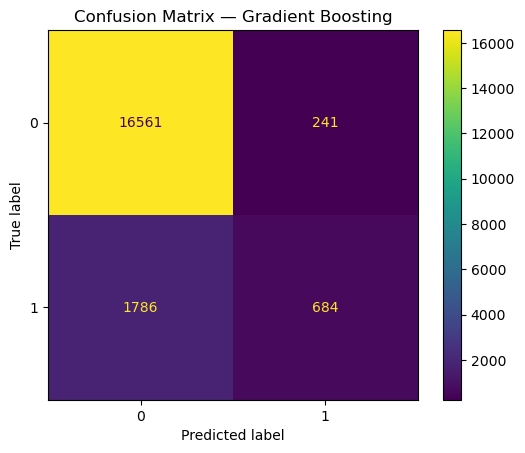

In [262]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

In [265]:
# Build Tableau dataset from the full reviewed-order modeling dataframe
df_tableau = model_df[[
    "order_id",
    "has_review",
    "is_dissatisfied",
    "delivery_delay",
    "delivery_deviation_abs",
    "order_value",
    "product_count",
    "avg_price_per_item",
    "prior_orders",
    "is_repeat_customer",
    "purchase_month",
    "purchase_dow"
]].copy()

# Add model predictions
df_tableau["y_pred_proba"] = best_model.predict_proba(X)[:, 1]
df_tableau["risk_flag"] = (df_tableau["y_pred_proba"] > 0.6).astype(int)

# Export
df_tableau.to_csv("../data/processed/final_tableau_dataset.csv", index=False)

### 7. Feature Importance

In [263]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

importances = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)

delivery_delay            0.136853
product_count             0.060858
order_value               0.008545
purchase_month            0.005622
delivery_deviation_abs    0.002596
is_repeat_customer        0.000000
prior_orders             -0.000153
avg_price_per_item       -0.000406
purchase_dow             -0.000798
dtype: float64

### 8. Final Interpretation

#### Key insights from the model

The model highlights which aspects of the post-purchase experience are most strongly associated with dissatisfaction.

The strongest signals are expected to come from delivery performance and order-level experience features, while customer-history variables may provide additional context.

These insights can be used to:
- identify high-risk orders
- prioritize operational improvements
- design proactive customer experience interventions

#### Business interpretation

The model is not intended as a purely predictive tool, but as a decision-support system.

It can help answer:
- Which orders are most at risk of dissatisfaction?
- Where should the company intervene to protect customer experience?
- Which operational factors have the greatest impact on perception?

In practice, this could support:
- proactive customer communication
- prioritization of delayed shipments
- targeted service recovery strategies